# 사과, 바나나, 오렌지 이미지 딥러닝으로 분류하기

- 사과, 바나나, 오렌지를 이미지 데이터를 기반으로 분류하기(다중 분류)
- 합성곱 신경망(CNN)을 이용해서 분류하기

참조 데이터셋 https://www.kaggle.com/datasets/afridi10/fruit-dataset

            - fruits_mini_dataset에서 apple, banana, orage 데이터를 활용

참조 코드 https://www.kaggle.com/code/vincee/intel-image-classification-cnn-keras/notebook

In [1]:
import cv2   #pip install opencv-python                       

# 과일 이미지들을 가져오는 함수
# path = 과일 이미지 폴더의 상위 폴더 (예:  ./train/apple  이라면 paht에는 ./train 만)
# fruit = 가져올 과일이 들어있는 폴더명 (예:  ./train/apple  이라면 apple)
def load_images(path):
    fruits = {'apple':0, 'banana':1, 'orange':2}
    images = []
    labels = []

    for fruit in fruits:
        print("loading:", path, fruit, fruits[fruit])
        path_dir = path+'/'+fruit
        file_list = os.listdir(path_dir)
        for file_name in file_list:
            img_path = path_dir+'/'+file_name     # 최종 이미지 파일의 path
            image = cv2.imread(img_path)          # 이미지 읽어오기
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (150, 150))
            images.append(image)
            labels.append(fruits[fruit])
        
    print("image count:", len(images))
    return images, labels

In [2]:
# 필요한 라이브러리 import
import numpy as np
import os
import matplotlib.pyplot as plt             
import seaborn as sns
from sklearn.utils import shuffle           
import tensorflow as tf                
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

np.random.seed(0)
tf.random.set_seed(0)

train_dir = './train' #학습 이미지가 있는 폴더 위치
test_dir = './test'  #테스트 이미지가 있는 폴더 위치

# load_images 함수를 사용하여 train 폴더 하위의 모든 이미지를 가져오기
# 이미즈는 x_train에 담고, y_train에는 목표 레이블을 담는다.
x_train, y_train = load_images(train_dir) # train 폴더밑에 있는 과일 이미지 가져오기

x_train = np.array(x_train)
y_train = np.array(y_train)

# 케라스는 각각 데이터가 0과 1 사이의 값일 때 최적의 성능을 보이기 때문에 
# 현재 0 ~ 255사이의 정수를 갖는 배열의 항목값을 0 ~ 1 사이의 값으로 나타내도록, 
# 실수로  255 로 나눔 
x_train = x_train / 255.0 

# 과일이 순서대로 담겨 있으므로 학습을 위해 순서를 섞어준다.
x_train, y_train = shuffle(x_train, y_train, random_state=0)

loading: ./train apple 0
loading: ./train banana 1
loading: ./train orange 2
image count: 900


### 딥러닝 모델 구성및 학습

In [3]:
# 입력 데이터의 형태 확인
x_train.shape

(900, 150, 150, 3)

In [4]:
# 모델 생성
model = Sequential()

#첫번째 컨볼루션 층과 풀링 층
model.add(Conv2D(32, (3, 3), activation = 'relu', input_shape = (150, 150, 3)))
model.add(MaxPooling2D(2,2))

#두번째 컨볼루션 층과 풀링 층
model.add(Conv2D(32, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(2,2))

# 2차원 배열을 1차원으로 변환
model.add(Flatten())

# 분류 학습을 위한 층
model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))

#학습 과정 설정
model.compile(optimizer = 'Adam', 
              loss = 'sparse_categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10)

Epoch 1/10
29/29 [==============================] - 5s 165ms/step - loss: 1.6153 - accuracy: 0.3378
Epoch 2/10
29/29 [==============================] - 5s 166ms/step - loss: 1.0406 - accuracy: 0.4533
Epoch 3/10
29/29 [==============================] - 5s 166ms/step - loss: 0.9372 - accuracy: 0.5511
Epoch 4/10
29/29 [==============================] - 5s 168ms/step - loss: 0.8307 - accuracy: 0.6378
Epoch 5/10
29/29 [==============================] - 5s 165ms/step - loss: 0.6726 - accuracy: 0.7433
Epoch 6/10
29/29 [==============================] - 5s 165ms/step - loss: 0.4794 - accuracy: 0.8289
Epoch 7/10
29/29 [==============================] - 5s 166ms/step - loss: 0.3682 - accuracy: 0.8844
Epoch 8/10
29/29 [==============================] - 5s 166ms/step - loss: 0.2202 - accuracy: 0.9322
Epoch 9/10
29/29 [==============================] - 5s 165ms/step - loss: 0.1293 - accuracy: 0.9700
Epoch 10/10
29/29 [==============================] - 5s 165ms/step - loss: 0.0716 - accuracy: 0.9833

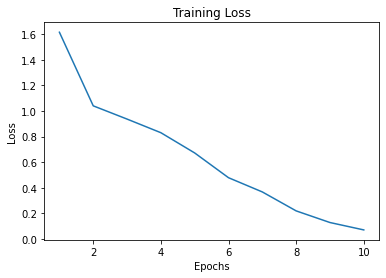

In [5]:
# 학습 진행 이력을 그래프로 보기 : 모델 평가

loss = history.history['loss'] #손실함수의 결과값
epochs = range(1,len(loss)+1)   #학습 횟수

plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(epochs, loss) # 학습 횟수를 x축 값으로, 손실결과값을 y축 값으로
plt.show()

### 모델 평가하기
- 테스트 데이터를 가져오기
- 테스트 데이터를 기반으로 정확도 측정
- 예측 결과 보기

In [6]:
# load_images 함수를 사용하여 test 폴더 하위의 모든 이미지를 가져오기
# 이미즈는 x_test에 담고, y_test에는 목표 레이블을 담는다.
x_test, y_test = load_images(test_dir)
x_test = np.array(x_test)
x_test = x_test / 255.0 
y_test = np.array(y_test)

loading: ./test apple 0
loading: ./test banana 1
loading: ./test orange 2
image count: 300


In [7]:
# 테스트 데이터로 예측 정확도를 확인
loss_value, accuracy = model.evaluate(x_test,y_test)
print('손실값:',loss_value)
print('예측 정확도:', accuracy)

10/10 [==============================] - 0s 35ms/step - loss: 1.3593 - accuracy: 0.6900
손실값: 1.3593090772628784
예측 정확도: 0.6899999976158142


10/10 [==============================] - 0s 33ms/step
정답: 0
예측: 0


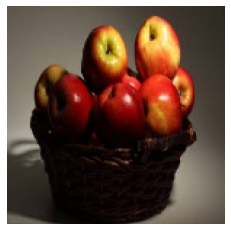

In [12]:
# 테스트 데이터로 예측
prd = model.predict(x_test).argmax(axis=1)

# 이미지로 예측 결과 확인하기
label = y_test[30]
image = x_test[30]
print('정답:',label)
print('예측:',prd[30])
plt.figure()
plt.imshow(image)
plt.axis('off')
plt.show()

In [10]:
# 이미지 데이터를 준비 함수
import cv2   #pip install opencv-python                       

def load_images(path):
    fruits = {'apple':0, 'banana':1, 'orange':2}
    images = []
    labels = []

    for fruit in fruits:
        print("loading:", path, fruit, fruits[fruit])
        path_dir = path+'/'+fruit
        file_list = os.listdir(path_dir)
        for file_name in file_list:
            img_path = path_dir+'/'+file_name     
            image = cv2.imread(img_path)          
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (150, 150))
            images.append(image)
            labels.append(fruits[fruit])
        
    print("image count:", len(images))
    return images, labels

# 필요한 라이브러리 import
import numpy as np
import os
import matplotlib.pyplot as plt             
import seaborn as sns
from sklearn.utils import shuffle           
import tensorflow as tf                
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

np.random.seed(0)
tf.random.set_seed(0)

train_dir = './train' 
test_dir = './test' 

x_train, y_train = load_images(train_dir) 

x_train = np.array(x_train)
y_train = np.array(y_train)
x_train = x_train / 255.0 
x_train, y_train = shuffle(x_train, y_train, random_state=0)

# 입력 데이터의 형태 확인
x_train.shape

model = Sequential()

model.add(Conv2D(32, (3, 3), activation = 'relu', 
                 input_shape = (150, 150, 3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(32, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer = 'Adam', 
              loss = 'sparse_categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10)

# 테스트 데이터 준비
x_test, y_test = load_images(test_dir)
x_test = np.array(x_test)
x_test = x_test / 255.0 
y_test = np.array(y_test)

# 정확도를 확인
loss_value, accuracy = model.evaluate(x_test,y_test)
print('손실값:',loss_value)
print('예측 정확도:', accuracy)

# 예측하고 확인하기
prd = model.predict(x_test).argmax(axis=1)

label = y_test[30]
image = x_test[30]
print('정답:',label)
print('예측:',prd[30])
plt.figure()
plt.imshow(image)
plt.axis('off')
plt.show()